# Compare one reconstruction against the ground-truth shoe

This notebook is meant for visual debugging, not just headline numbers.

It uses the production `mesh_metrics` evaluator for alignment and metric computation, then shows the actual ground-truth regions that are missing and the actual predicted regions that are extra.

The main workflow is:
1. Change only the paths in the setup cell.
2. Pick the method you want to inspect.
3. Run all cells.
4. Read the geometry table, then inspect the missing and extra surface plots.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# =========================
# EDIT ONLY THIS CELL
# =========================
PROJECT_ROOT = Path('/storage/Abhinay/Shell_Gaussian')
PYTHON = Path('/storage/Abhinay/home_ab5298/anaconda3/envs/shellgaussianenv/bin/python')

# One Blender evaluation scene = one ground-truth mesh.
SCENE = Path('/storage/Abhinay/home_ab5298/dataset/datasets/processed/gshell/golden_set_evaluation/air_jordan_1')

# Add or remove methods here. Change only these paths.
PREDICTIONS = {
    'G-Shell': PROJECT_ROOT / 'baselines/GShell/output/fab_evaluation_tight256_diverse/nike-air-jordan_depth_polycam_pose_depthfix_tight256/pass1/mesh.obj',
    'NeuralUDF': PROJECT_ROOT / 'baselines/NeuralUDF/output/open_surface_full/air_jordan_1/udf_open/udf_meshes/udf_res512_step300000.ply',
    'NeuS2': PROJECT_ROOT / 'baselines/NeuS2/output/golden_set_evaluation_blender_final/air_jordan_1/meshes/00015000_world.obj',
    'SuGaR': PROJECT_ROOT / 'baselines/SuGaR/output/golden_set_evaluation_blender_final/air_jordan_1/refined/refined_mesh.obj',
}

# Pick one method from PREDICTIONS.
SELECTED_METHOD = 'G-Shell'

# Notebook output folder for alignment/metric JSONs.
OUTPUT = PROJECT_ROOT / 'mesh_metrics/output/notebook_compare' / SCENE.name / SELECTED_METHOD.lower().replace(' ', '_')

# Recompute metrics if True. Set False to reuse existing JSONs and aligned mesh.
RUN_EVALUATION = True

# If the method used only the 150 train views, leave this as 'train'.
TRAINING_VIEW_SET = 'train'

# Surface points farther than this threshold from the other mesh are highlighted.
# This is expressed as a percent of the GT bounding-box diagonal.
ERROR_THRESHOLD_PERCENT = 1.0

# More points give denser pictures but take longer.
SURFACE_SAMPLE_COUNT = 40000

# Optional full held-out view metrics. Usually leave False for fast geometry inspection.
RUN_FULL_HELDOUT_METRICS = False

assert SELECTED_METHOD in PREDICTIONS, SELECTED_METHOD
PREDICTION = Path(PREDICTIONS[SELECTED_METHOD])
assert PREDICTION.is_file(), PREDICTION
assert (SCENE / 'reference_mesh.ply').is_file(), SCENE

print('Scene:   ', SCENE)
print('Method:  ', SELECTED_METHOD)
print('Predict: ', PREDICTION)
print('Output:  ', OUTPUT)
display(pd.DataFrame({'method': list(PREDICTIONS.keys()), 'prediction_path': [str(path) for path in PREDICTIONS.values()]}))


Scene:    /storage/Abhinay/home_ab5298/dataset/datasets/processed/gshell/golden_set_evaluation/air_jordan_1
Method:   G-Shell
Predict:  /storage/Abhinay/Shell_Gaussian/baselines/GShell/output/fab_evaluation_tight256_diverse/nike-air-jordan_depth_polycam_pose_depthfix_tight256/pass1/mesh.obj
Output:   /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_compare/air_jordan_1/g-shell


,method,prediction_path
0,G-Shell,/storage/Abhinay/Shell_Gaussian/baselines/GShe...
1,NeuralUDF,/storage/Abhinay/Shell_Gaussian/baselines/Neur...
2,NeuS2,/storage/Abhinay/Shell_Gaussian/baselines/NeuS...
3,SuGaR,/storage/Abhinay/Shell_Gaussian/baselines/SuGa...


## Run the production evaluator

This notebook does not carry its own alignment or metric implementation. It calls `python -m mesh_metrics.evaluate_mesh` and then visualizes the result.


In [2]:
if RUN_EVALUATION:
    command = [
        str(PYTHON), '-m', 'mesh_metrics.evaluate_mesh',
        '--prediction', str(PREDICTION),
        '--scene', str(SCENE),
        '--output', str(OUTPUT),
        '--training-view-set', TRAINING_VIEW_SET,
        '--save-aligned',
        '--alignment-iterations', '250',
        '--alignment-tolerance', '1e-6',
        '--metric-samples', '200000',
        '--query-chunk-size', '250000',
    ]
    if RUN_FULL_HELDOUT_METRICS:
        print('Running full geometry + held-out view evaluation...')
    else:
        print('Running geometry-only evaluation for faster visual inspection...')
        command.append('--geometry-only')
    print(' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print('Skipping evaluator run and reusing files already in:', OUTPUT)


Running geometry-only evaluation for faster visual inspection...
/storage/Abhinay/home_ab5298/anaconda3/envs/shellgaussianenv/bin/python -m mesh_metrics.evaluate_mesh --prediction /storage/Abhinay/Shell_Gaussian/baselines/GShell/output/fab_evaluation_tight256_diverse/nike-air-jordan_depth_polycam_pose_depthfix_tight256/pass1/mesh.obj --scene /storage/Abhinay/home_ab5298/dataset/datasets/processed/gshell/golden_set_evaluation/air_jordan_1 --output /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_compare/air_jordan_1/g-shell --training-view-set train --save-aligned --alignment-iterations 250 --alignment-tolerance 1e-6 --metric-samples 200000 --query-chunk-size 250000 --geometry-only
Evaluation written to /storage/Abhinay/Shell_Gaussian/mesh_metrics/output/notebook_compare/air_jordan_1/g-shell
{
  "accuracy_percent": 0.4782716577324551,
  "completeness_percent": 1.1779233871479664,
  "chamfer_l1_percent": 0.8280975224402106,
  "f_score_1_percent": 0.704409383044041,
  "normal_

In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mesh_metrics.mesh_io import load_mesh, sample_surface
from mesh_metrics.surface_queries import TriangleSurface

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

alignment_report = read_json(OUTPUT / 'alignment.json')
geometry_report = read_json(OUTPUT / 'geometry_metrics.json')
view_report = read_json(OUTPUT / 'view_metrics.json') if (OUTPUT / 'view_metrics.json').is_file() else None

ground_truth_mesh = load_mesh(SCENE / 'reference_mesh.ply')
aligned_mesh = load_mesh(OUTPUT / 'aligned_prediction.ply')

diagonal = float(geometry_report['ground_truth_bbox_diagonal'])
threshold_distance = diagonal * (ERROR_THRESHOLD_PERCENT / 100.0)
print(f'GT bbox diagonal: {diagonal:.6f}')
print(f'Highlight threshold: {ERROR_THRESHOLD_PERCENT:.3f}% of diagonal = {threshold_distance:.6f}')


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
GT bbox diagonal: 0.252214
Highlight threshold: 1.000% of diagonal = 0.002522


## Headline report

- **Accuracy** answers: where does the prediction have extra or misplaced surface?
- **Completeness** answers: where is real shoe surface missing from the prediction?
- The visual plots below show those two directions on the actual meshes.


In [4]:
headline = geometry_report['headline']
summary = pd.DataFrame({
    'Value': {
        'Scene': SCENE.name,
        'Method': SELECTED_METHOD,
        'Prediction path': str(PREDICTION),
        'Accuracy (%)': headline['accuracy_percent'],
        'Completeness (%)': headline['completeness_percent'],
        'Chamfer-L1 (%)': headline['chamfer_l1_percent'],
        'F-score@1%': headline['f_score_1_percent'],
        'Normal consistency': headline['normal_consistency'],
        'P95 distance (%)': headline['p95_distance_percent'],
    }
})
display(summary)

if view_report is not None:
    display(pd.DataFrame({'Held-out view metrics': view_report['headline']}))
else:
    print('Held-out view metrics were not computed in this run.')


,Value
Scene,air_jordan_1
Method,G-Shell
Prediction path,/storage/Abhinay/Shell_Gaussian/baselines/GShe...
Accuracy (%),0.478272
Completeness (%),1.177923
Chamfer-L1 (%),0.828098
F-score@1%,0.704409
Normal consistency,0.911202
P95 distance (%),3.675709


Held-out view metrics were not computed in this run.


In [5]:
prediction_points, _ = sample_surface(aligned_mesh, SURFACE_SAMPLE_COUNT, seed=21)
ground_truth_points, _ = sample_surface(ground_truth_mesh, SURFACE_SAMPLE_COUNT, seed=22)

prediction_to_gt = TriangleSurface(ground_truth_mesh).closest_points(prediction_points)
gt_to_prediction = TriangleSurface(aligned_mesh).closest_points(ground_truth_points)

extra_prediction_mask = prediction_to_gt.distances > threshold_distance
missing_ground_truth_mask = gt_to_prediction.distances > threshold_distance

extra_prediction_points = prediction_points[extra_prediction_mask]
extra_prediction_closest_gt = prediction_to_gt.points[extra_prediction_mask]
missing_ground_truth_points = ground_truth_points[missing_ground_truth_mask]
missing_ground_truth_closest_prediction = gt_to_prediction.points[missing_ground_truth_mask]

coverage_table = pd.DataFrame({
    'Value': {
        'Prediction samples': len(prediction_points),
        'Ground-truth samples': len(ground_truth_points),
        'Extra prediction samples': int(extra_prediction_mask.sum()),
        'Missing GT samples': int(missing_ground_truth_mask.sum()),
        'Extra prediction fraction': float(extra_prediction_mask.mean()),
        'Missing GT fraction': float(missing_ground_truth_mask.mean()),
    }
})
display(coverage_table)


,Value
Prediction samples,40000.00000
Ground-truth samples,40000.00000
Extra prediction samples,5038.00000
Missing GT samples,16216.00000
Extra prediction fraction,0.12595
Missing GT fraction,0.40540


In [6]:
def set_equal_3d_axes(axis, point_sets):
    valid = [points for points in point_sets if len(points) > 0]
    if not valid:
        return
    stacked = np.concatenate(valid, axis=0)
    center = 0.5 * (stacked.min(axis=0) + stacked.max(axis=0))
    radius = 0.55 * np.max(np.ptp(stacked, axis=0))
    radius = max(radius, 1e-6)
    axis.set_xlim(center[0] - radius, center[0] + radius)
    axis.set_ylim(center[1] - radius, center[1] + radius)
    axis.set_zlim(center[2] - radius, center[2] + radius)
    axis.set_box_aspect((1, 1, 1))
    axis.set_xlabel('X: heel to toe')
    axis.set_ylabel('Y: width')
    axis.set_zlabel('Z: up')

def scatter_mesh(axis, base_points, focus_points=None, base_color='lightgray', focus_color=None, title=''):
    axis.scatter(base_points[:, 0], base_points[:, 1], base_points[:, 2], s=0.18, c=base_color, alpha=0.18)
    if focus_points is not None and len(focus_points) > 0 and focus_color is not None:
        axis.scatter(focus_points[:, 0], focus_points[:, 1], focus_points[:, 2], s=0.8, c=focus_color, alpha=0.85)
    axis.set_title(title)
    set_equal_3d_axes(axis, [base_points, focus_points if focus_points is not None else np.empty((0, 3))])

def sample_rows(points, limit):
    if len(points) <= limit:
        return points
    indices = np.linspace(0, len(points) - 1, num=limit, dtype=np.int64)
    return points[indices]


## See the actual missing and extra regions

These are not abstract heat maps.

- **Red on GT** = real shoe surface that the prediction failed to recover well enough.
- **Blue on prediction** = predicted surface that does not correspond well to real GT surface.


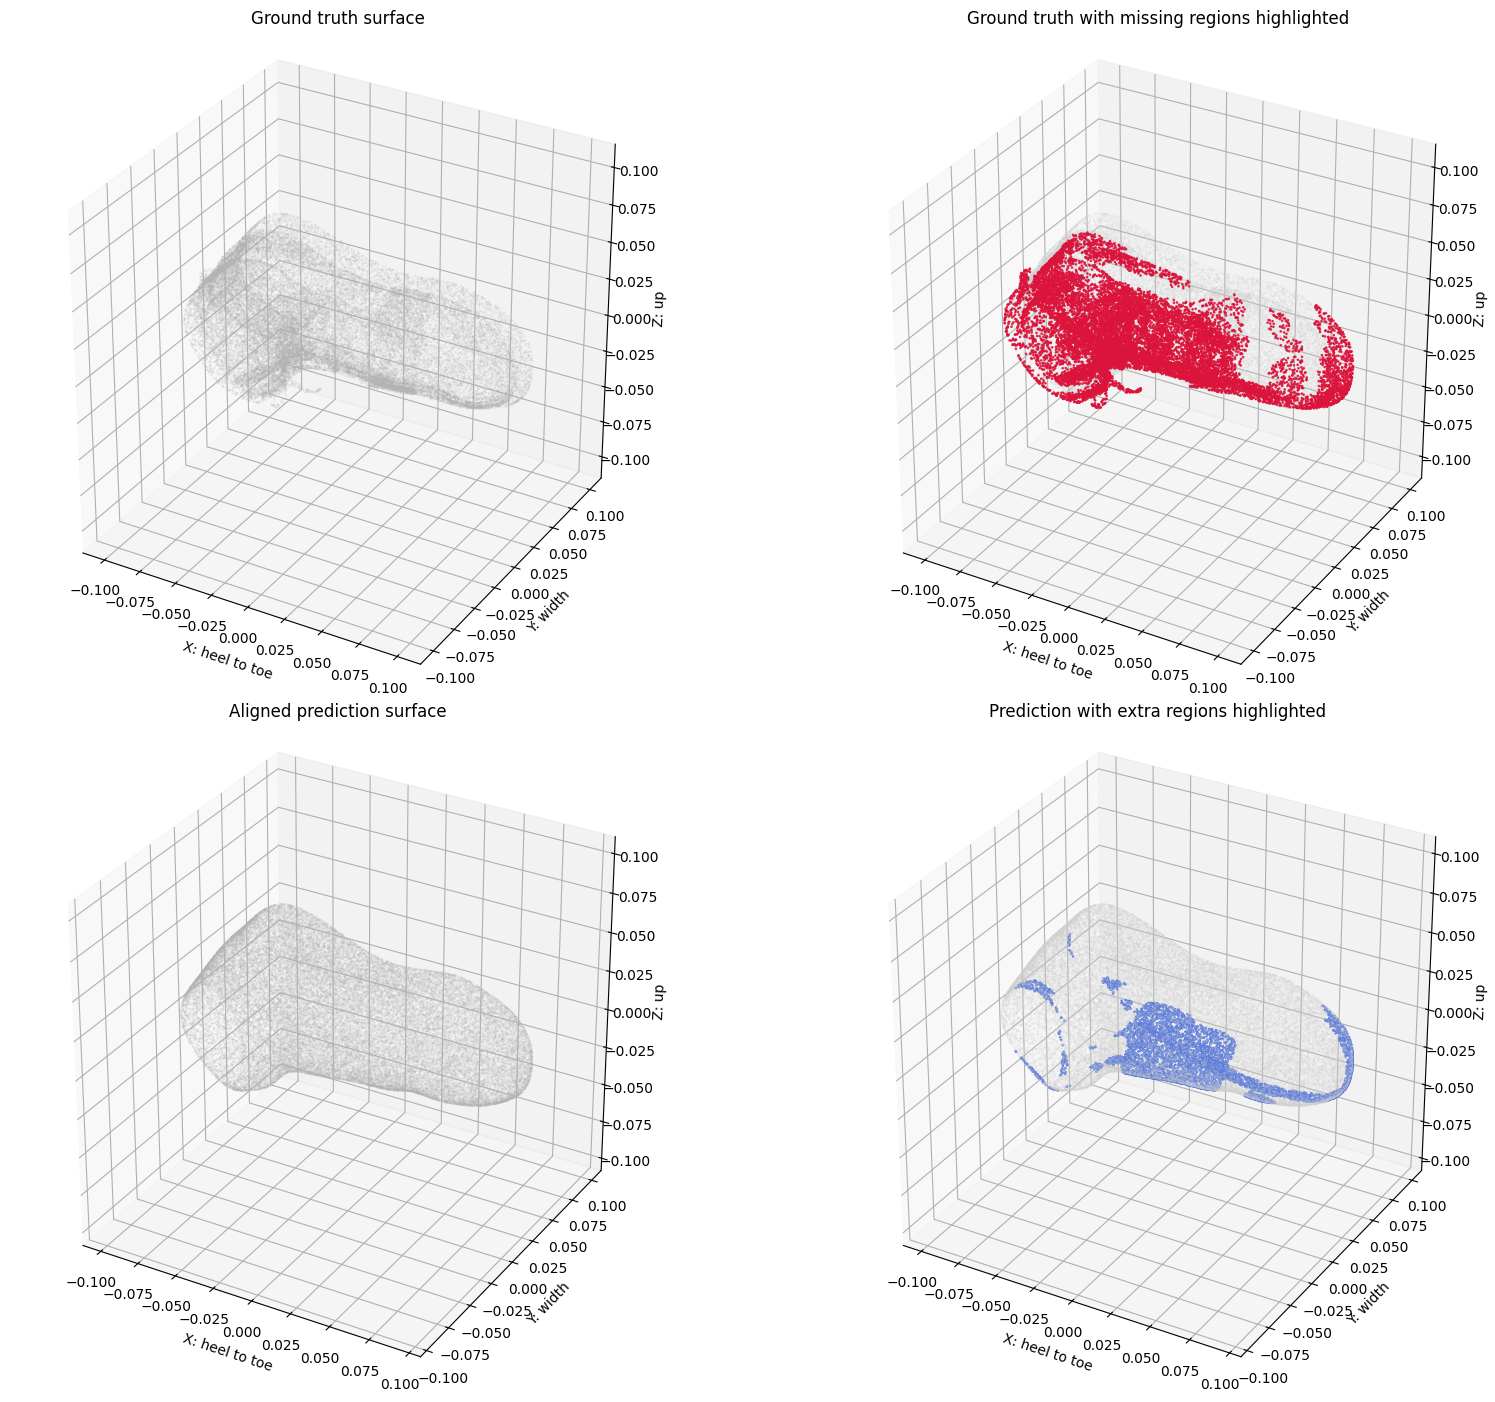

In [7]:
figure = plt.figure(figsize=(18, 14))

axis = figure.add_subplot(221, projection='3d')
scatter_mesh(axis, ground_truth_points, None, base_color='0.70', title='Ground truth surface')

axis = figure.add_subplot(222, projection='3d')
scatter_mesh(axis, ground_truth_points, missing_ground_truth_points, base_color='0.82', focus_color='crimson', title='Ground truth with missing regions highlighted')

axis = figure.add_subplot(223, projection='3d')
scatter_mesh(axis, prediction_points, None, base_color='0.70', title='Aligned prediction surface')

axis = figure.add_subplot(224, projection='3d')
scatter_mesh(axis, prediction_points, extra_prediction_points, base_color='0.82', focus_color='royalblue', title='Prediction with extra regions highlighted')

plt.tight_layout()
plt.show()


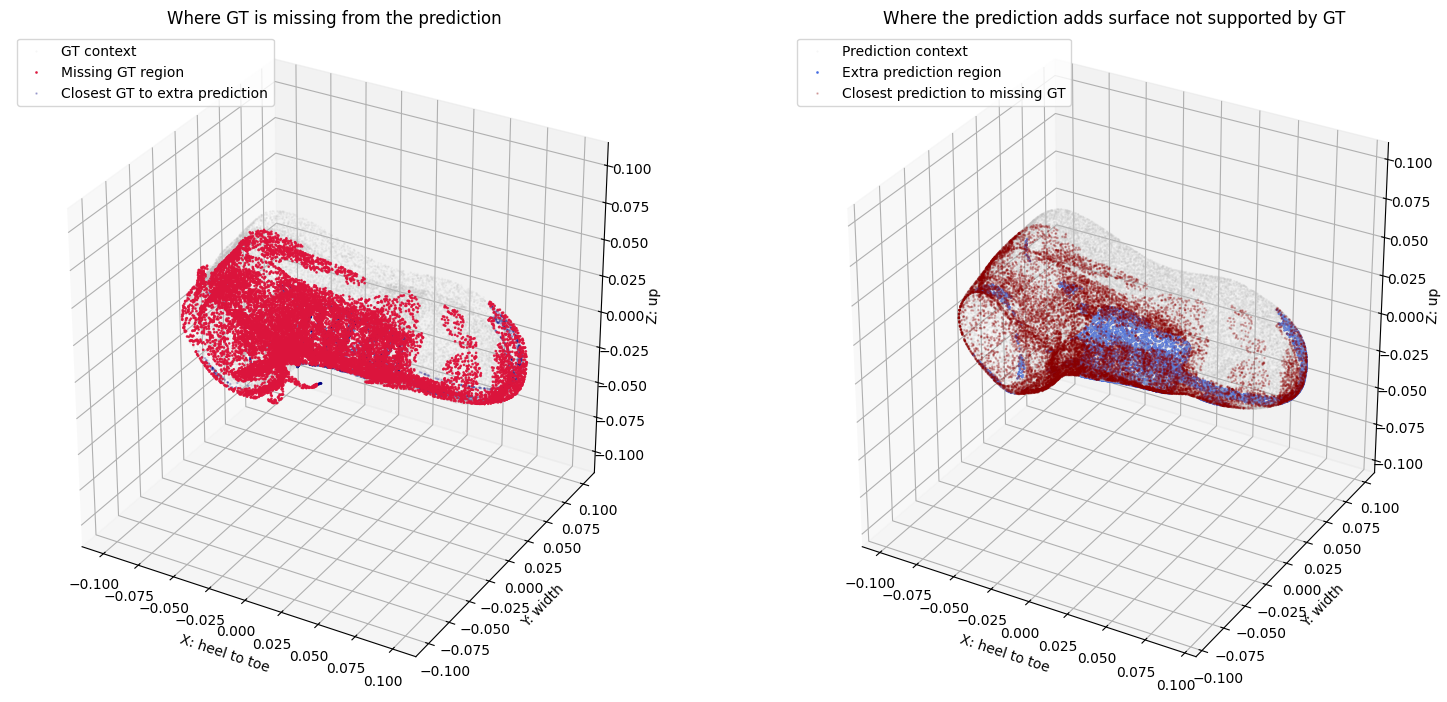

In [8]:
overlay_figure = plt.figure(figsize=(16, 7))

overlay_axis = overlay_figure.add_subplot(121, projection='3d')
overlay_axis.scatter(ground_truth_points[:, 0], ground_truth_points[:, 1], ground_truth_points[:, 2], s=0.18, c='0.75', alpha=0.15, label='GT context')
overlay_axis.scatter(missing_ground_truth_points[:, 0], missing_ground_truth_points[:, 1], missing_ground_truth_points[:, 2], s=0.9, c='crimson', alpha=0.88, label='Missing GT region')
overlay_axis.scatter(extra_prediction_closest_gt[:, 0], extra_prediction_closest_gt[:, 1], extra_prediction_closest_gt[:, 2], s=0.6, c='navy', alpha=0.25, label='Closest GT to extra prediction')
overlay_axis.set_title('Where GT is missing from the prediction')
set_equal_3d_axes(overlay_axis, [ground_truth_points, missing_ground_truth_points, extra_prediction_closest_gt])
overlay_axis.legend(loc='upper left')

overlay_axis = overlay_figure.add_subplot(122, projection='3d')
overlay_axis.scatter(prediction_points[:, 0], prediction_points[:, 1], prediction_points[:, 2], s=0.18, c='0.75', alpha=0.15, label='Prediction context')
overlay_axis.scatter(extra_prediction_points[:, 0], extra_prediction_points[:, 1], extra_prediction_points[:, 2], s=0.9, c='royalblue', alpha=0.88, label='Extra prediction region')
overlay_axis.scatter(missing_ground_truth_closest_prediction[:, 0], missing_ground_truth_closest_prediction[:, 1], missing_ground_truth_closest_prediction[:, 2], s=0.6, c='darkred', alpha=0.25, label='Closest prediction to missing GT')
overlay_axis.set_title('Where the prediction adds surface not supported by GT')
set_equal_3d_axes(overlay_axis, [prediction_points, extra_prediction_points, missing_ground_truth_closest_prediction])
overlay_axis.legend(loc='upper left')

plt.tight_layout()
plt.show()


## Closest-surface pair view

This view makes the metric direction even more concrete:

- left: red GT points that are missing, with black points showing where the prediction ended up being closest
- right: blue prediction points that are extra, with black points showing their closest GT surface


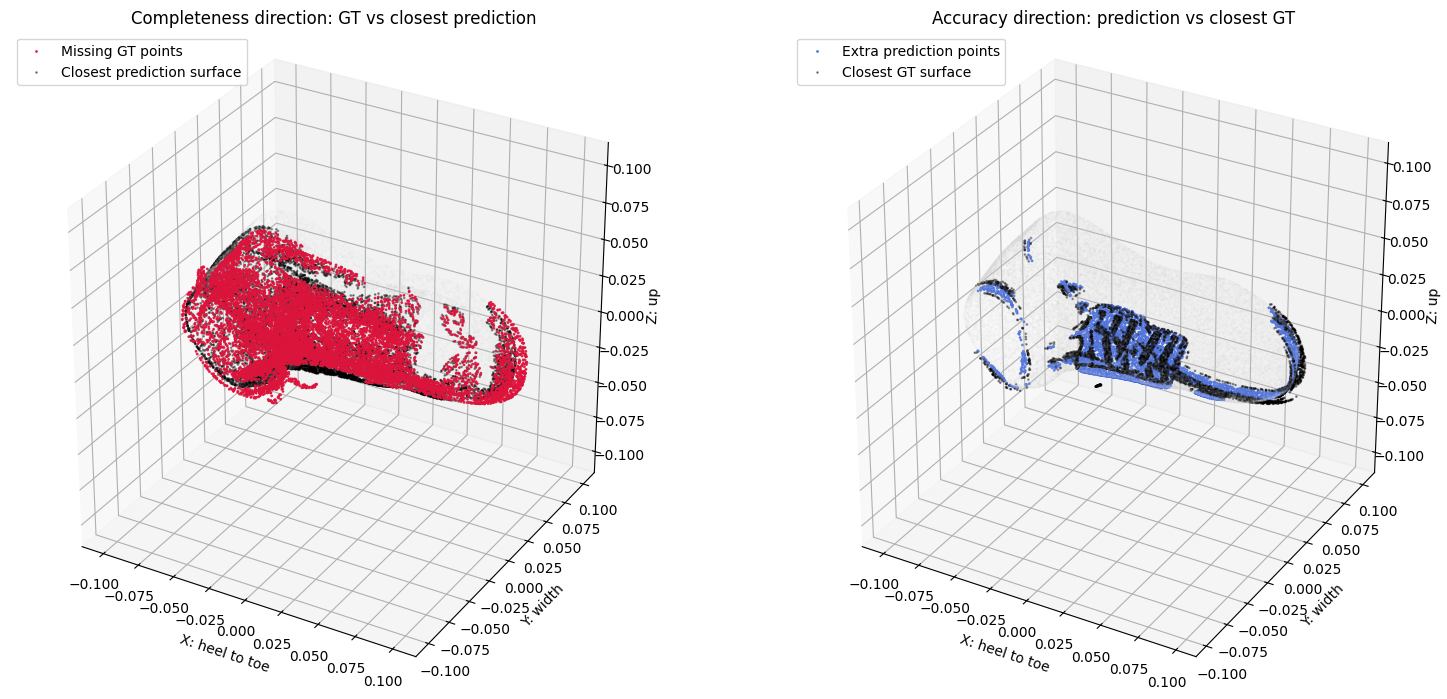

In [9]:
missing_subset = sample_rows(missing_ground_truth_points, 12000)
missing_closest_subset = sample_rows(missing_ground_truth_closest_prediction, 12000)
extra_subset = sample_rows(extra_prediction_points, 12000)
extra_closest_subset = sample_rows(extra_prediction_closest_gt, 12000)

figure = plt.figure(figsize=(16, 7))

axis = figure.add_subplot(121, projection='3d')
axis.scatter(ground_truth_points[:, 0], ground_truth_points[:, 1], ground_truth_points[:, 2], s=0.12, c='0.85', alpha=0.08)
axis.scatter(missing_subset[:, 0], missing_subset[:, 1], missing_subset[:, 2], s=1.0, c='crimson', alpha=0.88, label='Missing GT points')
axis.scatter(missing_closest_subset[:, 0], missing_closest_subset[:, 1], missing_closest_subset[:, 2], s=0.85, c='black', alpha=0.42, label='Closest prediction surface')
axis.set_title('Completeness direction: GT vs closest prediction')
set_equal_3d_axes(axis, [ground_truth_points, missing_subset, missing_closest_subset])
axis.legend(loc='upper left')

axis = figure.add_subplot(122, projection='3d')
axis.scatter(prediction_points[:, 0], prediction_points[:, 1], prediction_points[:, 2], s=0.12, c='0.85', alpha=0.08)
axis.scatter(extra_subset[:, 0], extra_subset[:, 1], extra_subset[:, 2], s=1.0, c='royalblue', alpha=0.88, label='Extra prediction points')
axis.scatter(extra_closest_subset[:, 0], extra_closest_subset[:, 1], extra_closest_subset[:, 2], s=0.85, c='black', alpha=0.42, label='Closest GT surface')
axis.set_title('Accuracy direction: prediction vs closest GT')
set_equal_3d_axes(axis, [prediction_points, extra_subset, extra_closest_subset])
axis.legend(loc='upper left')

plt.tight_layout()
plt.show()


## Optional held-out view metrics

If `RUN_FULL_HELDOUT_METRICS=False`, this cell simply tells you that the geometry inspection was run without the slower 30-view render pass.


In [10]:
if view_report is None:
    print('Held-out view metrics were skipped. Set RUN_FULL_HELDOUT_METRICS=True in the setup cell if you want them here too.')
else:
    per_view = pd.DataFrame(view_report['per_view'])
    display(pd.DataFrame({'Value': view_report['headline']}))
    display(per_view[['frame', 'elevation_deg', 'azimuth_deg', 'silhouette_iou', 'boundary_f_score', 'depth_mae_percent', 'depth_overlap_coverage']])


Held-out view metrics were skipped. Set RUN_FULL_HELDOUT_METRICS=True in the setup cell if you want them here too.


## Reading the plots

- If the **red GT points** cluster around the opening, footbed, heel, or outsole, the method is missing those parts.
- If the **blue prediction points** form sheets, blobs, or smoothed-over bridges, the method is adding unsupported geometry.
- If both red and blue are small, the geometry metrics should also be strong.
- The threshold is yours to control. Tighten it below `1.0%` to be stricter; loosen it if you want a more forgiving visual summary.
